In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

result_dir = Path("../dataset/CQI_Mobility_medium_region_2")   # 你存 result.npz 的目录
npz_files = sorted(result_dir.glob("*_result.npz"))

print(f"Found {len(npz_files)} result files")


Found 1000 result files


In [ ]:
def load_channel(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    cap = data["capacity"]
    sinr_db = data["sinr_db"]

    # object array -> stack
    if cap.dtype == object:
        cap = np.stack(cap, axis=0)
    cap = np.squeeze(cap, axis=(3,5,6))
    
    if sinr_db.dtype == object:
        sinr_db = np.stack(sinr_db, axis=0)
    sinr_db = np.squeeze(sinr_db, axis=(3,5,6))
    return cap, sinr_db


In [3]:
npz_path = npz_files[100]
capacity, sinr_db = load_channel(npz_path)
capacity.shape

(1200, 1, 4, 2)

In [4]:
sinr_db = sinr_db[:, 0, :]
sinr_db.shape

(1200, 4, 2)

In [5]:
capacity = capacity[:, 0, :]
capacity.shape

(1200, 4, 2)

In [ ]:
import numpy as np


def sticky_rx_single_ue(capacity, epsilon=0.3, seed=None, verbose=False):
    """
    Sticky RX-level exploration for a single UE.

    Parameters
    ----------
    capacity : np.ndarray
        Shape (N_sample, N_RX, N_TX)
    epsilon : float
        Exploration probability.
    seed : int or None
        Random seed.
    verbose : bool
        If True, print detailed link-capacity comparison at each exploration step.

    Returns
    -------
    results : dict
        {
            "serving_rx":       (N_sample,),
            "serving_tx":       (N_sample,),
            "serving_capacity": (N_sample,),
            "explore_flag":     (N_sample,),
            "switch_flag":      (N_sample,),
            "new_rx":           (N_sample,),   # np.nan if no exploration
        }
    """
    capacity = np.asarray(capacity)
    if capacity.ndim != 3:
        raise ValueError("capacity must have shape (N_sample, N_RX, N_TX)")

    N_sample, N_RX, N_TX = capacity.shape
    rng = np.random.default_rng(seed)

    serving_rx = np.full(N_sample, -1, dtype=int)
    serving_tx = np.full(N_sample, -1, dtype=int)
    serving_capacity = np.zeros(N_sample, dtype=capacity.dtype)

    explore_flag = np.zeros(N_sample, dtype=bool)
    switch_flag = np.zeros(N_sample, dtype=bool)
    new_rx_record = np.full(N_sample, np.nan, dtype=float)

    # --------------------------------------------------
    # t = 0: open all RX, choose global best (RX, TX)
    # --------------------------------------------------
    mat0 = capacity[0]  # (N_RX, N_TX)
    flat_idx = np.argmax(mat0)
    rx0, tx0 = np.unravel_index(flat_idx, mat0.shape)

    serving_rx[0] = rx0
    serving_tx[0] = tx0
    serving_capacity[0] = mat0[rx0, tx0]

    if verbose:
        print(f"[t=0] INIT")
        print(f"  selected: RX={rx0}, TX={tx0}, cap={serving_capacity[0]:.4f}")

    # --------------------------------------------------
    # t >= 1
    # --------------------------------------------------
    for t in range(1, N_sample):
        prev_rx = serving_rx[t - 1]
        prev_tx = serving_tx[t - 1]

        # Keep previous serving link
        if rng.random() <= (1.0 - epsilon):
            serving_rx[t] = prev_rx
            serving_tx[t] = prev_tx
            serving_capacity[t] = capacity[t, prev_rx, prev_tx]

        # Explore: open one new RX, compare old RX and new RX
        else:
            explore_flag[t] = True

            candidate_rxs = [rx for rx in range(N_RX) if rx != prev_rx]
            rx_new = rng.choice(candidate_rxs)
            new_rx_record[t] = float(rx_new)

            rx_pair = [prev_rx, rx_new]
            submat = capacity[t, rx_pair, :]  # shape (2, N_TX)

            # Compare both old RX and new RX over all TX
            flat_idx = np.argmax(submat)
            local_rx_idx, best_tx = np.unravel_index(flat_idx, submat.shape)

            best_rx = rx_pair[local_rx_idx]
            best_cap = submat[local_rx_idx, best_tx]

            serving_rx[t] = best_rx
            serving_tx[t] = best_tx
            serving_capacity[t] = best_cap

            switched = (best_rx != prev_rx)
            switch_flag[t] = switched

            if verbose:
                print(f"\n[t={t}] EXPLORE")
                print(f"  prev serving: RX={prev_rx}, TX={prev_tx}, "
                      f"cap_now={capacity[t, prev_rx, prev_tx]:.4f}")
                print(f"  new_rx tried: RX={rx_new}")

                for i, rx in enumerate(rx_pair):
                    caps = submat[i]
                    best_tx_i = int(np.argmax(caps))
                    best_cap_i = caps[best_tx_i]

                    tag = "OLD" if rx == prev_rx else "NEW"
                    print(f"  RX {rx} ({tag}) all TX caps: {caps}")
                    print(f"      best on RX {rx}: TX={best_tx_i}, cap={best_cap_i:.4f}")

                print(f"  ==> selected: RX={best_rx}, TX={best_tx}, cap={best_cap:.4f}")
                print(f"  ==> switched RX: {switched}")

    return {
        "serving_rx": serving_rx,
        "serving_tx": serving_tx,
        "serving_capacity": serving_capacity,
        "explore_flag": explore_flag,
        "switch_flag": switch_flag,
        "new_rx": new_rx_record,
    }

In [9]:
# for t in range(1200):
#     print(
#         f"\t t={t:3d}, \t "
#         f"\t RX={res['serving_rx'][t]}, \t "
#         f"\t TX={res['serving_tx'][t]}, \t "
#         f"\t cap={res['serving_capacity'][t]:.4f}, \t "
#         f"\t explore={res['explore_flag'][t]},\t "
#         f"\t new_rx={res['new_rx'][t]},\t "
#         f"\t switch_flag={res['switch_flag'][t]}\t "
#     )

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def plot_selected_vs_all_links(
    capacity,
    serving_capacity,
    serving_rx=None,
    serving_tx=None,
    switch_flag=None,
    figsize=(15, 6),
    alpha_links=0.35,
    linewidth_links=1.0,
    linewidth_selected=2.5,
    title="Selected capacity vs. all ground-truth links",
):
    """
    Plot selected serving capacity against all ground-truth link capacities.

    Parameters
    ----------
    capacity : np.ndarray
        Shape (N_sample, N_RX, N_TX)
    serving_capacity : np.ndarray
        Shape (N_sample,)
    serving_rx : np.ndarray or None
        Shape (N_sample,), optional
    serving_tx : np.ndarray or None
        Shape (N_sample,), optional
    switch_flag : np.ndarray or None
        Shape (N_sample,), optional
    figsize : tuple
        Figure size
    alpha_links : float
        Alpha for all link curves
    linewidth_links : float
        Line width for all link curves
    linewidth_selected : float
        Line width for selected curve
    title : str
        Plot title
    """
    capacity = np.asarray(capacity)
    serving_capacity = np.asarray(serving_capacity)

    if capacity.ndim != 3:
        raise ValueError("capacity must have shape (N_sample, N_RX, N_TX)")
    if serving_capacity.ndim != 1:
        raise ValueError("serving_capacity must have shape (N_sample,)")

    N_sample, N_RX, N_TX = capacity.shape
    t = np.arange(N_sample)

    plt.figure(figsize=figsize)

    # --------------------------------------------------
    # Plot all ground-truth links
    # --------------------------------------------------
    for rx in range(N_RX):
        for tx in range(N_TX):
            plt.plot(
                t,
                capacity[:, rx, tx],
                alpha=alpha_links,
                linewidth=linewidth_links,
                label=f"GT RX{rx}-TX{tx}"
            )

    # --------------------------------------------------
    # Plot selected serving capacity
    # --------------------------------------------------
    plt.plot(
        t,
        serving_capacity,
        linewidth=linewidth_selected,
        label="Selected serving capacity"
    )

    # --------------------------------------------------
    # Mark switch times if provided
    # --------------------------------------------------
    if switch_flag is not None:
        switch_flag = np.asarray(switch_flag).astype(bool)
        switch_idx = np.where(switch_flag)[0]
        if len(switch_idx) > 0:
            plt.scatter(
                switch_idx,
                serving_capacity[switch_idx],
                s=35,
                marker="o",
                label="RX switch"
            )

    plt.xlabel("Time step")
    plt.ylabel("Capacity")
    plt.title(title)
    plt.grid(True, alpha=0.3)

    # legend太多时放到外面
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Optional: print selected link summary
    # --------------------------------------------------
    if serving_rx is not None and serving_tx is not None:
        serving_rx = np.asarray(serving_rx)
        serving_tx = np.asarray(serving_tx)

        print("First 10 selected links:")
        for i in range(min(10, N_sample)):
            print(
                f"t={i:3d}, RX={serving_rx[i]}, TX={serving_tx[i]}, "
                f"cap={serving_capacity[i]:.4f}"
            )

In [12]:
# cap_single = capacity[:, 0, :, :]   # (1200, 4, 2)

# res = sticky_rx_single_ue(
#     cap_single,
#     epsilon=0.2,
#     seed=42,
#     verbose=False
# )

# plot_selected_vs_all_links(
#     capacity=cap_single,
#     serving_capacity=res["serving_capacity"],
#     serving_rx=res["serving_rx"],
#     serving_tx=res["serving_tx"],
#     switch_flag=res["switch_flag"],
#     title="Sticky RX exploration: selected capacity vs all links"
# )

In [13]:
import numpy as np
import matplotlib.pyplot as plt


def plot_selected_vs_best(capacity, serving_capacity, switch_flag=None, figsize=(15, 5)):
    """
    Plot selected serving capacity vs global best capacity at each time.
    capacity shape: (N_sample, N_RX, N_TX)
    serving_capacity shape: (N_sample,)
    """
    capacity = np.asarray(capacity)
    serving_capacity = np.asarray(serving_capacity)

    N_sample = capacity.shape[0]
    t = np.arange(N_sample)

    global_best = np.max(capacity, axis=(1, 2))

    plt.figure(figsize=figsize)
    plt.plot(t, global_best, linewidth=1.5, label="Global best capacity")
    plt.plot(t, serving_capacity, linewidth=1.5, label="Selected serving capacity")

    if switch_flag is not None:
        switch_flag = np.asarray(switch_flag).astype(bool)
        idx = np.where(switch_flag)[0]
        if len(idx) > 0:
            plt.scatter(idx, serving_capacity[idx], s=35, marker="o", c="black", label="RX switch")

    plt.xlabel("Time step")
    plt.ylabel("Capacity")
    plt.title("Selected capacity vs global best capacity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    gap = global_best - serving_capacity
    print(f"Average gap to global best: {np.mean(gap):.4f}")
    print(f"Max gap to global best: {np.max(gap):.4f}")

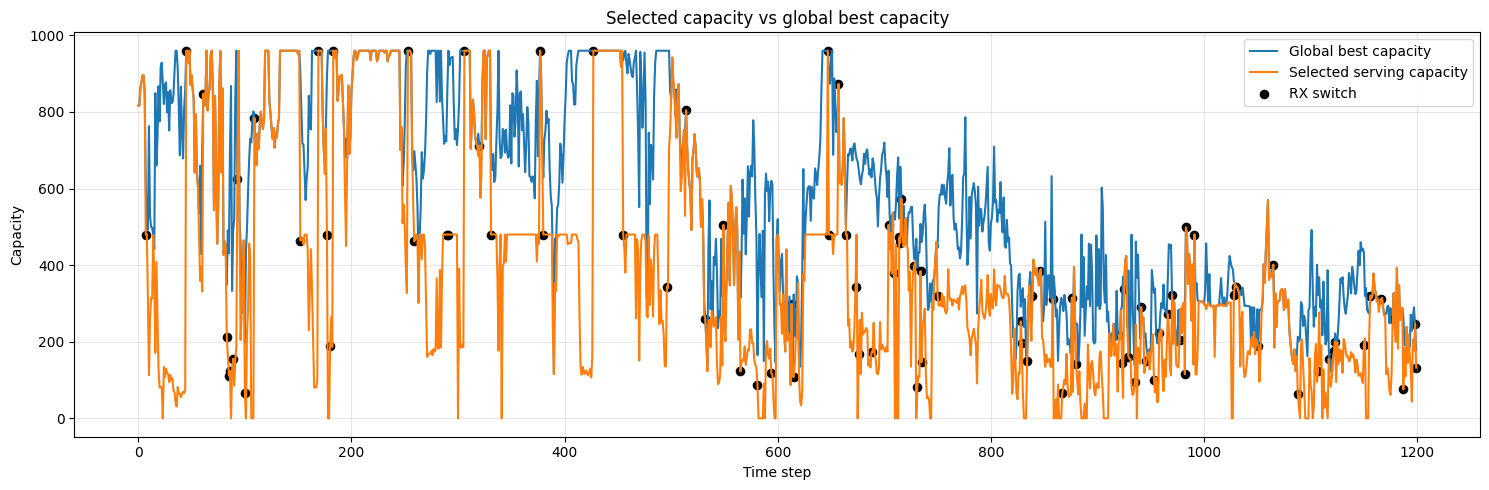

Average gap to global best: 195.8684
Max gap to global best: 960.0000


In [ ]:
plot_selected_vs_best(
    capacity=capacity,
    serving_capacity=results["serving_capacity"],
    switch_flag=results["switch_flag"]
)

In [15]:
import numpy as np


def summarize_selection_performance(capacity, res):
    """
    capacity: (N_sample, N_RX, N_TX)
    res: output dict from sticky_rx_single_ue()

    Returns
    -------
    stats : dict
    """
    capacity = np.asarray(capacity)

    serving_rx = np.asarray(res["serving_rx"])
    serving_tx = np.asarray(res["serving_tx"])
    serving_capacity = np.asarray(res["serving_capacity"])
    switch_flag = np.asarray(res["switch_flag"]).astype(bool)

    N_sample, N_RX, N_TX = capacity.shape

    # global best capacity
    best_capacity = np.max(capacity, axis=(1, 2))

    # global best link
    best_flat_idx = np.argmax(capacity.reshape(N_sample, -1), axis=1)
    best_rx, best_tx = np.unravel_index(best_flat_idx, (N_RX, N_TX))

    # whether selected the global best link
    selected_best_flag = (serving_rx == best_rx) & (serving_tx == best_tx)

    # statistics
    best_selection_percentage = 100.0 * np.mean(selected_best_flag)
    num_switches = int(np.sum(switch_flag))
    avg_best_capacity = float(np.mean(best_capacity))
    avg_selected_capacity = float(np.mean(serving_capacity))

    stats = {
        "best_selection_percentage": best_selection_percentage,
        "num_switches": num_switches,
        "avg_best_capacity": avg_best_capacity,
        "avg_selected_capacity": avg_selected_capacity,
        "avg_gap": float(np.mean(best_capacity - serving_capacity)),
        "max_gap": float(np.max(best_capacity - serving_capacity)),
        "selected_best_flag": selected_best_flag,
        "best_capacity": best_capacity,
        "best_rx": best_rx,
        "best_tx": best_tx,
    }

    print(f"Selected global best link: {best_selection_percentage:.2f}%")
    print(f"Number of RX switches: {num_switches}")
    print(f"Average global best capacity: {avg_best_capacity:.4f}")
    print(f"Average selected capacity: {avg_selected_capacity:.4f}")
    print(f"Average gap: {stats['avg_gap']:.4f}")
    print(f"Max gap: {stats['max_gap']:.4f}")

    return stats

In [16]:
stats = summarize_selection_performance(cap_single, res)

NameError: name 'cap_single' is not defined